# Benchmark Model Training

### Logistic Regression, Random Forest, XGBoost


## Logistic Regression (Mean Rating)


In [45]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))


from helpers import ModelData
from constants import PROCESSED_DATA_FOLDER
import numpy as np

model_data = ModelData.from_pickle(PROCESSED_DATA_FOLDER / "processed_data.pkl")
model_data

ModelData(n_total=921, n_train=921, n_obs=64887)

In [46]:
# Random Seed für Reproduzierbarkeit
SEED = 42

In [47]:
# Aufteilung in business_covariates und rating_stats

# Business covariates (ohne Rating-Statistiken und OHNE Closed!)
business_features = [
    "density",
    "Checkin",
    "category",
    "chain",
    "Price.Level",
    "Restaurant.Size",
    "Number.of.Seats",
    "ZRI",
    "Distance.To.City.Centre",
    "Age",
]

# Rating statistics
rating_features = [
    "VAR",
    "MEAN",
    "ENTR",
    "COUNT",
    "ONE_STAR",
    "TWO_STAR",
    "THREE_STAR",
    "FOUR_STAR",
    "FIVE_STAR",
    "l_COUNT",
]

print(f"Business features: {len(business_features)} Variablen")
print(f"Rating features: {len(rating_features)} Variablen")
print(f"Gesamt: {len(business_features) + len(rating_features)} Variablen")
print("\nWICHTIG: 'Closed' ist die Zielvariable und wird NICHT als Feature verwendet!")

# Train/Test Split basierend auf train_indices
train_indices = model_data.train_indices
if train_indices is not None:
    test_indices = np.array(
        [
            i
            for i in range(len(model_data.benchmark_covariates))
            if i not in train_indices
        ]
    )
else:
    train_indices = np.arange(int(0.8 * len(model_data.benchmark_covariates)))
    test_indices = np.arange(
        int(0.8 * len(model_data.benchmark_covariates)),
        len(model_data.benchmark_covariates),
    )

print(f"\nTrain/Test Split:")
print(f"  Training samples: {len(train_indices)}")
print(f"  Test samples: {len(test_indices)}")
print(f"  Total: {len(train_indices) + len(test_indices)}")

Business features: 10 Variablen
Rating features: 10 Variablen
Gesamt: 20 Variablen

WICHTIG: 'Closed' ist die Zielvariable und wird NICHT als Feature verwendet!

Train/Test Split:
  Training samples: 500
  Test samples: 421
  Total: 921


## Model 1: Logistic Regression mit Mean Rating


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import numpy as np

# Target Variable vorbereiten
y = model_data.benchmark_covariates["Closed"].map({"Open": 0, "Closed": 1}).values

# Model 1: Nur Mean Rating
X_mean = model_data.benchmark_covariates[["MEAN"]].values

# Train/Test Split
X_mean_train, X_mean_test = X_mean[train_indices], X_mean[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

# Train Logistic Regression
lr_mean = LogisticRegression(random_state=SEED, max_iter=1000)
lr_mean.fit(X_mean_train, y_train)

# Predictions auf Train und Test
y_pred_mean_train = lr_mean.predict(X_mean_train)
y_proba_mean_train = lr_mean.predict_proba(X_mean_train)[:, 1]

y_pred_mean_test = lr_mean.predict(X_mean_test)
y_proba_mean_test = lr_mean.predict_proba(X_mean_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 1: Logistic Regression mit Mean Rating")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_mean_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_mean_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_mean_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_mean_test):.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_mean_test, target_names=["Open", "Closed"]))

# Koeffizienten
print(f"\nKoeffizient MEAN: {lr_mean.coef_[0][0]:.4f}")
print(f"Intercept: {lr_mean.intercept_[0]:.4f}")

MODEL 1: Logistic Regression mit Mean Rating

TRAIN Performance:
  Accuracy: 0.7700
  ROC-AUC: 0.5025

TEST Performance:
  Accuracy: 0.7387
  ROC-AUC: 0.5030

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.74      1.00      0.85       311
      Closed       0.00      0.00      0.00       110

    accuracy                           0.74       421
   macro avg       0.37      0.50      0.42       421
weighted avg       0.55      0.74      0.63       421


Koeffizient MEAN: 0.1275
Intercept: -1.6644


/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.p

## Model 2: Logistic Regression mit Business Covariates


In [49]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Model 2: Business Covariates
df_business = model_data.benchmark_covariates[business_features].copy()

# Kategorische Variablen identifizieren
categorical_cols = ["category"]
numeric_cols = [col for col in business_features if col not in categorical_cols]

# One-Hot Encoding
df_business_encoded = pd.get_dummies(
    df_business, columns=categorical_cols, drop_first=True
)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_business = SimpleImputer(strategy="median")
scaler_business = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_business_encoded.iloc[train_indices][numeric_cols]
imputer_business.fit(numeric_train)
scaler_business.fit(imputer_business.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_business.transform(df_business_encoded[numeric_cols])
numeric_data = scaler_business.transform(numeric_data_imputed)

# NaN-Werte nach Imputation prüfen
n_missing = pd.DataFrame(numeric_data_imputed, columns=numeric_cols).isna().sum().sum()
print(f"NaN-Werte nach Imputation: {n_missing}")

# Kombiniere Features
X_business = pd.DataFrame(
    numeric_data, columns=numeric_cols, index=df_business_encoded.index
)
dummy_cols = [col for col in df_business_encoded.columns if col not in numeric_cols]
X_business = pd.concat([X_business, df_business_encoded[dummy_cols]], axis=1)

print(f"Business Features Shape: {X_business.shape}")

# Train/Test Split
X_business_train = X_business.iloc[train_indices]
X_business_test = X_business.iloc[test_indices]

# Train Logistic Regression
lr_business = LogisticRegression(random_state=SEED, max_iter=1000)
lr_business.fit(X_business_train, y_train)

# Predictions
y_pred_business_train = lr_business.predict(X_business_train)
y_proba_business_train = lr_business.predict_proba(X_business_train)[:, 1]

y_pred_business_test = lr_business.predict(X_business_test)
y_proba_business_test = lr_business.predict_proba(X_business_test)[:, 1]

# Evaluation
print("\n" + "=" * 60)
print("MODEL 2: Logistic Regression mit Business Covariates")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_business_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_business_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_business_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_business_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(y_test, y_pred_business_test, target_names=["Open", "Closed"])
)

# Top 10 wichtigste Features
coef_df = pd.DataFrame(
    {"feature": X_business.columns, "coefficient": lr_business.coef_[0]}
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 wichtigste Features:")
print(coef_df.head(10)[["feature", "coefficient"]])

NaN-Werte nach Imputation: 0
Business Features Shape: (921, 17)

MODEL 2: Logistic Regression mit Business Covariates

TRAIN Performance:
  Accuracy: 0.7620
  ROC-AUC: 0.7527

TEST Performance:
  Accuracy: 0.7340
  ROC-AUC: 0.7304

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.74      0.99      0.85       311
      Closed       0.25      0.01      0.02       110

    accuracy                           0.73       421
   macro avg       0.49      0.50      0.43       421
weighted avg       0.61      0.73      0.63       421


Top 10 wichtigste Features:
                     feature  coefficient
15            category_Salad    -1.219765
2                      chain    -0.897206
11        category_Fast Food    -0.676769
16  category_Speciality Food     0.504976
12          category_Mexican    -0.420084
13            category_Other     0.302305
6                        ZRI     0.212077
7    Distance.To.City.Centre     0.180910
0     

## Model 3: Logistic Regression mit allen Variablen (Business + Rating Stats)


In [50]:
# Model 3: Alle Variablen (Business Covariates + Rating Stats)
all_features = business_features + rating_features

# Daten vorbereiten
df_all = model_data.benchmark_covariates[all_features].copy()

# Kategorische Variablen
categorical_cols = ["category"]
numeric_cols = [col for col in all_features if col not in categorical_cols]

# One-Hot Encoding
df_all_encoded = pd.get_dummies(df_all, columns=categorical_cols, drop_first=True)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_all = SimpleImputer(strategy="median")
scaler_all = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_all_encoded.iloc[train_indices][numeric_cols]
imputer_all.fit(numeric_train)
scaler_all.fit(imputer_all.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_all.transform(df_all_encoded[numeric_cols])
numeric_data = scaler_all.transform(numeric_data_imputed)

# NaN-Werte nach Imputation prüfen
n_missing = pd.DataFrame(numeric_data_imputed, columns=numeric_cols).isna().sum().sum()
print(f"NaN-Werte nach Imputation: {n_missing}")

# Kombiniere Features
X_all = pd.DataFrame(numeric_data, columns=numeric_cols, index=df_all_encoded.index)
dummy_cols = [col for col in df_all_encoded.columns if col not in numeric_cols]
X_all = pd.concat([X_all, df_all_encoded[dummy_cols]], axis=1)

print(f"All Features Shape: {X_all.shape}")

# Train/Test Split
X_all_train = X_all.iloc[train_indices]
X_all_test = X_all.iloc[test_indices]

# Train Logistic Regression
lr_all = LogisticRegression(random_state=SEED, max_iter=1000)
lr_all.fit(X_all_train, y_train)

# Predictions
y_pred_all_train = lr_all.predict(X_all_train)
y_proba_all_train = lr_all.predict_proba(X_all_train)[:, 1]

y_pred_all_test = lr_all.predict(X_all_test)
y_proba_all_test = lr_all.predict_proba(X_all_test)[:, 1]

# Evaluation
print("\n" + "=" * 60)
print("MODEL 3: Logistic Regression mit ALLEN Variablen")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_all_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_all_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_all_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_all_test):.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_all_test, target_names=["Open", "Closed"]))

# Top 10 wichtigste Features
coef_df_all = pd.DataFrame({"feature": X_all.columns, "coefficient": lr_all.coef_[0]})
coef_df_all["abs_coefficient"] = coef_df_all["coefficient"].abs()
coef_df_all = coef_df_all.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 wichtigste Features:")
print(coef_df_all.head(10)[["feature", "coefficient"]])

NaN-Werte nach Imputation: 0
All Features Shape: (921, 27)

MODEL 3: Logistic Regression mit ALLEN Variablen

TRAIN Performance:
  Accuracy: 0.8200
  ROC-AUC: 0.8266

TEST Performance:
  Accuracy: 0.7957
  ROC-AUC: 0.7986

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.81      0.95      0.87       311
      Closed       0.71      0.37      0.49       110

    accuracy                           0.80       421
   macro avg       0.76      0.66      0.68       421
weighted avg       0.78      0.80      0.77       421


Top 10 wichtigste Features:
                     feature  coefficient
2                      chain    -1.053177
25            category_Salad    -0.960134
26  category_Speciality Food     0.937366
21        category_Fast Food    -0.769243
16                 FOUR_STAR     0.672773
20            category_Cafes     0.586241
22          category_Mexican    -0.421126
18                   l_COUNT    -0.350679
6              

## Vergleich der drei Benchmark-Modelle


VERGLEICH DER BENCHMARK-MODELLE
              Model          Features  Train Accuracy  Test Accuracy  Train ROC-AUC  Test ROC-AUC
        Mean Rating MEAN (1 Variable)           0.770       0.738717       0.502473      0.503025
Business Covariates      17 Variablen           0.762       0.733967       0.752727      0.730371
       All Features      27 Variablen           0.820       0.795724       0.826606      0.798626


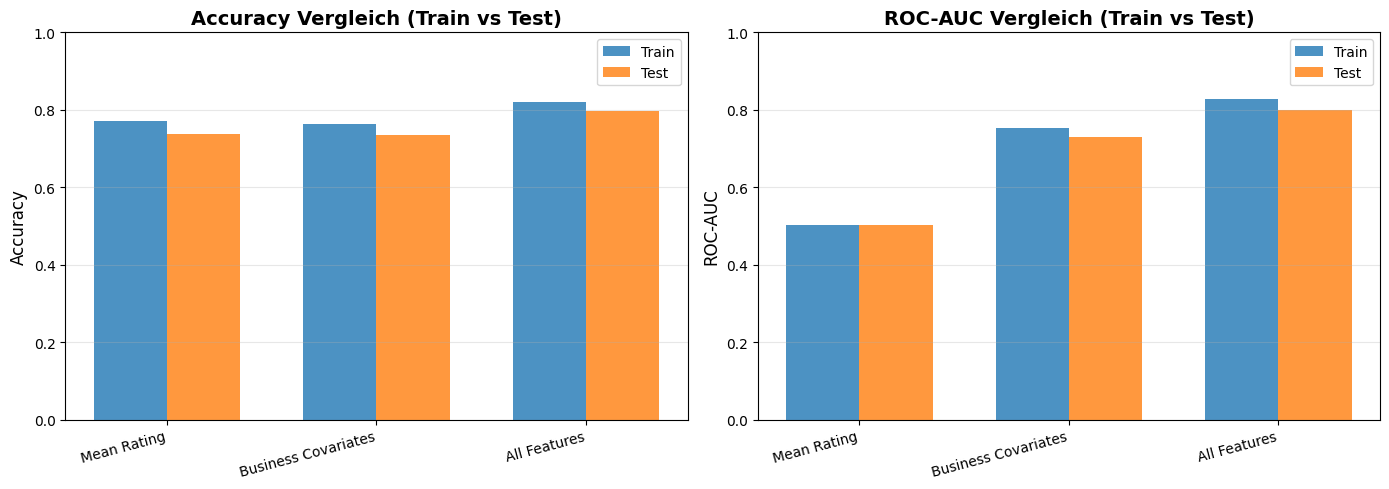


Bestes Modell (Test ROC-AUC): All Features
Test ROC-AUC: 0.7986
Test Accuracy: 0.7957


In [51]:
# Vergleichstabelle erstellen (TEST Performance!)
import pandas as pd

results_comparison = pd.DataFrame(
    {
        "Model": ["Mean Rating", "Business Covariates", "All Features"],
        "Features": [
            "MEAN (1 Variable)",
            f"{len(X_business.columns)} Variablen",
            f"{len(X_all.columns)} Variablen",
        ],
        "Train Accuracy": [
            accuracy_score(y_train, y_pred_mean_train),
            accuracy_score(y_train, y_pred_business_train),
            accuracy_score(y_train, y_pred_all_train),
        ],
        "Test Accuracy": [
            accuracy_score(y_test, y_pred_mean_test),
            accuracy_score(y_test, y_pred_business_test),
            accuracy_score(y_test, y_pred_all_test),
        ],
        "Train ROC-AUC": [
            roc_auc_score(y_train, y_proba_mean_train),
            roc_auc_score(y_train, y_proba_business_train),
            roc_auc_score(y_train, y_proba_all_train),
        ],
        "Test ROC-AUC": [
            roc_auc_score(y_test, y_proba_mean_test),
            roc_auc_score(y_test, y_proba_business_test),
            roc_auc_score(y_test, y_proba_all_test),
        ],
    }
)

print("=" * 80)
print("VERGLEICH DER BENCHMARK-MODELLE")
print("=" * 80)
print(results_comparison.to_string(index=False))

# Visualisierung
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Vergleich
x = np.arange(len(results_comparison))
width = 0.35

axes[0].bar(
    x - width / 2,
    results_comparison["Train Accuracy"],
    width,
    label="Train",
    color="#1f77b4",
    alpha=0.8,
)
axes[0].bar(
    x + width / 2,
    results_comparison["Test Accuracy"],
    width,
    label="Test",
    color="#ff7f0e",
    alpha=0.8,
)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Accuracy Vergleich (Train vs Test)", fontsize=14, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_comparison["Model"], rotation=15, ha="right")
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# ROC-AUC Vergleich
axes[1].bar(
    x - width / 2,
    results_comparison["Train ROC-AUC"],
    width,
    label="Train",
    color="#1f77b4",
    alpha=0.8,
)
axes[1].bar(
    x + width / 2,
    results_comparison["Test ROC-AUC"],
    width,
    label="Test",
    color="#ff7f0e",
    alpha=0.8,
)
axes[1].set_ylabel("ROC-AUC", fontsize=12)
axes[1].set_title("ROC-AUC Vergleich (Train vs Test)", fontsize=14, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_comparison["Model"], rotation=15, ha="right")
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Bestes Modell identifizieren (basierend auf Test ROC-AUC)
best_model_idx = results_comparison["Test ROC-AUC"].idxmax()
print(
    f"\nBestes Modell (Test ROC-AUC): {results_comparison.loc[best_model_idx, 'Model']}"
)
print(f"Test ROC-AUC: {results_comparison.loc[best_model_idx, 'Test ROC-AUC']:.4f}")
print(f"Test Accuracy: {results_comparison.loc[best_model_idx, 'Test Accuracy']:.4f}")

# Random Forest Models

---


## Model 4: Random Forest mit Mean Rating


In [52]:
from sklearn.ensemble import RandomForestClassifier

# Model 4: Random Forest mit Mean Rating
rf_mean = RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=10)
rf_mean.fit(X_mean_train, y_train)

# Predictions
y_pred_rf_mean_train = rf_mean.predict(X_mean_train)
y_proba_rf_mean_train = rf_mean.predict_proba(X_mean_train)[:, 1]

y_pred_rf_mean_test = rf_mean.predict(X_mean_test)
y_proba_rf_mean_test = rf_mean.predict_proba(X_mean_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 4: Random Forest mit Mean Rating")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_rf_mean_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_rf_mean_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_mean_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_rf_mean_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(y_test, y_pred_rf_mean_test, target_names=["Open", "Closed"])
)

# Feature Importance
print(f"\nFeature Importance: MEAN = {rf_mean.feature_importances_[0]:.4f}")

MODEL 4: Random Forest mit Mean Rating

TRAIN Performance:
  Accuracy: 0.8680
  ROC-AUC: 0.9754

TEST Performance:
  Accuracy: 0.6770
  ROC-AUC: 0.5169

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.75      0.86      0.80       311
      Closed       0.30      0.17      0.22       110

    accuracy                           0.68       421
   macro avg       0.52      0.51      0.51       421
weighted avg       0.63      0.68      0.65       421


Feature Importance: MEAN = 1.0000


## Model 5: Random Forest mit Business Covariates


In [53]:
# Model 5: Random Forest mit Business Covariates
rf_business = RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=10)
rf_business.fit(X_business_train, y_train)

# Predictions
y_pred_rf_business_train = rf_business.predict(X_business_train)
y_proba_rf_business_train = rf_business.predict_proba(X_business_train)[:, 1]

y_pred_rf_business_test = rf_business.predict(X_business_test)
y_proba_rf_business_test = rf_business.predict_proba(X_business_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 5: Random Forest mit Business Covariates")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_rf_business_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_rf_business_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_business_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_rf_business_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(
        y_test, y_pred_rf_business_test, target_names=["Open", "Closed"]
    )
)

# Top 10 Feature Importances
feature_importance_df = pd.DataFrame(
    {"feature": X_business.columns, "importance": rf_business.feature_importances_}
)
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)

print("\nTop 10 wichtigste Features:")
print(feature_importance_df.head(10))

MODEL 5: Random Forest mit Business Covariates

TRAIN Performance:
  Accuracy: 0.9900
  ROC-AUC: 0.9992

TEST Performance:
  Accuracy: 0.7743
  ROC-AUC: 0.7695

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.79      0.94      0.86       311
      Closed       0.65      0.30      0.41       110

    accuracy                           0.77       421
   macro avg       0.72      0.62      0.64       421
weighted avg       0.75      0.77      0.74       421


Top 10 wichtigste Features:
                     feature  importance
4            Restaurant.Size    0.161097
5            Number.of.Seats    0.137682
7    Distance.To.City.Centre    0.114941
1                    Checkin    0.114533
6                        ZRI    0.104288
8                        Age    0.101244
0                    density    0.087773
2                      chain    0.062257
3                Price.Level    0.023215
16  category_Speciality Food    0.017041


## Model 6: Random Forest mit allen Variablen (Business + Rating Stats)


In [54]:
# Model 6: Random Forest mit allen Variablen
rf_all = RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=10)
rf_all.fit(X_all_train, y_train)

# Predictions
y_pred_rf_all_train = rf_all.predict(X_all_train)
y_proba_rf_all_train = rf_all.predict_proba(X_all_train)[:, 1]

y_pred_rf_all_test = rf_all.predict(X_all_test)
y_proba_rf_all_test = rf_all.predict_proba(X_all_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 6: Random Forest mit ALLEN Variablen")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_rf_all_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_rf_all_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_all_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_rf_all_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(y_test, y_pred_rf_all_test, target_names=["Open", "Closed"])
)

# Top 10 Feature Importances
feature_importance_df_all = pd.DataFrame(
    {"feature": X_all.columns, "importance": rf_all.feature_importances_}
)
feature_importance_df_all = feature_importance_df_all.sort_values(
    "importance", ascending=False
)

print("\nTop 10 wichtigste Features:")
print(feature_importance_df_all.head(10))

MODEL 6: Random Forest mit ALLEN Variablen

TRAIN Performance:
  Accuracy: 0.9980
  ROC-AUC: 1.0000

TEST Performance:
  Accuracy: 0.7933
  ROC-AUC: 0.8236

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.79      0.98      0.87       311
      Closed       0.81      0.27      0.41       110

    accuracy                           0.79       421
   macro avg       0.80      0.63      0.64       421
weighted avg       0.80      0.79      0.75       421


Top 10 wichtigste Features:
                    feature  importance
16                FOUR_STAR    0.108421
4           Restaurant.Size    0.084638
5           Number.of.Seats    0.073999
6                       ZRI    0.055557
17                FIVE_STAR    0.054032
15               THREE_STAR    0.049614
7   Distance.To.City.Centre    0.048148
11                     ENTR    0.046919
10                     MEAN    0.046728
12                    COUNT    0.045828


## Vergleich Random Forest Modelle


VERGLEICH RANDOM FOREST MODELLE
                  Model          Features  Train Accuracy  Test Accuracy  Train ROC-AUC  Test ROC-AUC
        RF: Mean Rating MEAN (1 Variable)           0.868       0.676960       0.975381      0.516881
RF: Business Covariates      17 Variablen           0.990       0.774347       0.999187      0.769483
       RF: All Features      27 Variablen           0.998       0.793349       1.000000      0.823560


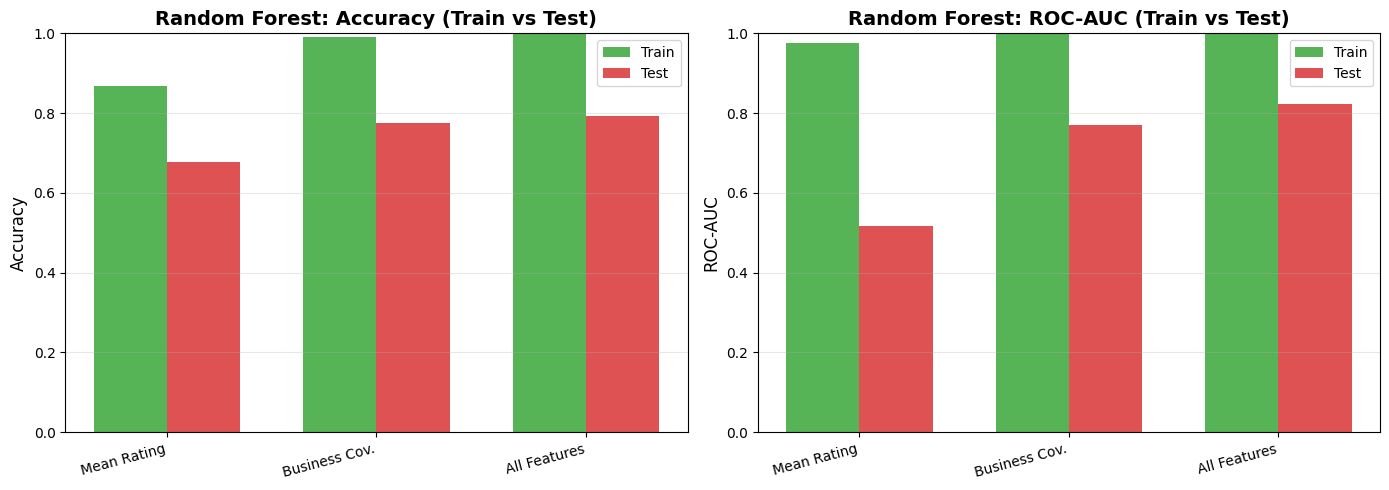


Bestes Random Forest Modell (Test ROC-AUC): RF: All Features
Test ROC-AUC: 0.8236
Test Accuracy: 0.7933


In [55]:
# Vergleich Random Forest Modelle
rf_results = pd.DataFrame(
    {
        "Model": ["RF: Mean Rating", "RF: Business Covariates", "RF: All Features"],
        "Features": [
            "MEAN (1 Variable)",
            f"{len(X_business.columns)} Variablen",
            f"{len(X_all.columns)} Variablen",
        ],
        "Train Accuracy": [
            accuracy_score(y_train, y_pred_rf_mean_train),
            accuracy_score(y_train, y_pred_rf_business_train),
            accuracy_score(y_train, y_pred_rf_all_train),
        ],
        "Test Accuracy": [
            accuracy_score(y_test, y_pred_rf_mean_test),
            accuracy_score(y_test, y_pred_rf_business_test),
            accuracy_score(y_test, y_pred_rf_all_test),
        ],
        "Train ROC-AUC": [
            roc_auc_score(y_train, y_proba_rf_mean_train),
            roc_auc_score(y_train, y_proba_rf_business_train),
            roc_auc_score(y_train, y_proba_rf_all_train),
        ],
        "Test ROC-AUC": [
            roc_auc_score(y_test, y_proba_rf_mean_test),
            roc_auc_score(y_test, y_proba_rf_business_test),
            roc_auc_score(y_test, y_proba_rf_all_test),
        ],
    }
)

print("=" * 80)
print("VERGLEICH RANDOM FOREST MODELLE")
print("=" * 80)
print(rf_results.to_string(index=False))

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(rf_results))
width = 0.35

# Accuracy
axes[0].bar(
    x - width / 2,
    rf_results["Train Accuracy"],
    width,
    label="Train",
    color="#2ca02c",
    alpha=0.8,
)
axes[0].bar(
    x + width / 2,
    rf_results["Test Accuracy"],
    width,
    label="Test",
    color="#d62728",
    alpha=0.8,
)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title(
    "Random Forest: Accuracy (Train vs Test)", fontsize=14, fontweight="bold"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    ["Mean Rating", "Business Cov.", "All Features"], rotation=15, ha="right"
)
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# ROC-AUC
axes[1].bar(
    x - width / 2,
    rf_results["Train ROC-AUC"],
    width,
    label="Train",
    color="#2ca02c",
    alpha=0.8,
)
axes[1].bar(
    x + width / 2,
    rf_results["Test ROC-AUC"],
    width,
    label="Test",
    color="#d62728",
    alpha=0.8,
)
axes[1].set_ylabel("ROC-AUC", fontsize=12)
axes[1].set_title(
    "Random Forest: ROC-AUC (Train vs Test)", fontsize=14, fontweight="bold"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    ["Mean Rating", "Business Cov.", "All Features"], rotation=15, ha="right"
)
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Bestes Random Forest Modell
best_rf_idx = rf_results["Test ROC-AUC"].idxmax()
print(
    f"\nBestes Random Forest Modell (Test ROC-AUC): {rf_results.loc[best_rf_idx, 'Model']}"
)
print(f"Test ROC-AUC: {rf_results.loc[best_rf_idx, 'Test ROC-AUC']:.4f}")
print(f"Test Accuracy: {rf_results.loc[best_rf_idx, 'Test Accuracy']:.4f}")